In [10]:
# Grib2 ECM FAX78 700 Divergence, 850 T Wind 天気図作成
#  （OMGがないため、収束・発散をハッチする）
#  USA領域にも対応
#
#  2023/7/23 Ryuta Kurora
#
import math
import pygrib
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime
import sys
#
import metpy.calc as mpcalc
from metpy.units import units
from scipy.ndimage import maximum_filter, minimum_filter
#
#import argparse

In [11]:
# GRIB2データファイルの格納先フォルダー名
data_fld="./data/ecm/"
#
# ECMWF GRIB2の読み込む初期値の年月日時をUTCで指定する。
i_year =2023
i_month = 5
i_day = 23
i_hourZ = 6
#
# 予想時間を与える。
i_ft = 0
#
# 気圧面を指定
tagHpDiv = 700  # 発散
tagHp    = 850  # 気温・風
#
## GPVの切り出し領域の指定：(lonW,latS)-(lonE,latN)の矩形                                                                                                      
latS=-20
latN=80
lonW=70
lonE=190
#
# 描画する範囲の大まかな指定
## 描画指定
# 基準の経度  JAPAN:140 USA:270
set_central_longitude=140
flag_border=False
# 地図の描画範囲指定
n_area=0
if n_area == 0:
    i_area = [108, 156, 17, 55]  #FEAX 極東                                                                   
    str_area = ""
elif n_area == 1:
    i_area = [115, 151, 20, 50]  #fx85 日本付近                                                               
    str_area = "_j"
elif n_area == 2:
    i_area = [105,180,0,65]      #ASAS                                                                        
    str_area = "_a"
elif n_area == 9:
    set_central_longitude=270
    i_area = [238, 286, 17, 55]  # USA
    str_area = "_usa"
    lonW=210  # JAPAN 70
    lonE=330  # JAPAN 190
    flag_border=True
else:
    i_area = [108, 156, 17, 55]  #FEAX 極東                                                                   
    str_area = ""
#
# 緯線・経線の指定
dlon,dlat=10,10   # 10度ごとに
# 温度(等値線の間隔を指定)
levels_tmp0  =np.arange(-60, 42,  3) # 等値線                              
levels_tmp0i =np.arange(-60, 42,  3) # 等値線 数字                    
levels_tmp1  =np.arange(-60, 42, 15) # 等値線 太線                  
# 鉛直流
levels_div_hat = [-20, -10, -5, -2, 2, 5, 10]
levels_div_hat_color = ['red','orange','gray', 'white', 'yellow', 'skyblue']
#
## スムージングのためのパラメータ
passes=16   # 高度のスムージングの繰り返し回数
s_n = 9     # 9 or 5


In [12]:
## 緯度経度で指定したポイントの図上の座標などを取得する関数 transform_lonlat_to_figure() 
# 図法の座標 => pixel座標 => 図の座標　と3回の変換を行う
#  　pixel座標: plt.figureで指定した大きさxDPIに合わせ、左下を原点とするpixelで測った座標   
#  　図の座標: axesで指定した範囲を(0,1)x(0,1)とする座標
# 3つの座標を出力する
#    図の座標, Pixel座標, 図法の座標
def transform_lonlat_to_figure(lonlat, ax, proj):
    # lonlat:経度と緯度  (lon, lat) 
    # ax: Axes図の座標系    ex. fig.add_subplot()の戻り値
    # proj: axで指定した図法 
    #
    # 例 緯度経度をpointで与え、ステレオ図法る場合
    #    point = (140.0,35.0)
    #    proj= ccrs.Stereographic(central_latitude=60, central_longitude=140) 
    #    fig = plt.figure(figsize=(20,16))
    #    ax = fig.add_subplot(1, 1, 1, projection=proj)
    #    ax.set_extent([108, 156, 17, 55], ccrs.PlateCarree())
    #
    ## 図法の変換
    # 参照  https://scitools.org.uk/cartopy/docs/v0.14/crs/index.html                    
    point_proj = proj.transform_point(*lonlat, ccrs.PlateCarree())
    #
    # pixel座標へ変換
    # 参照　https://matplotlib.org/stable/tutorials/advanced/transforms_tutorial.html
    point_pix = ax.transData.transform(point_proj)
    #
    # 図の座標へ変換                                                           
    point_fig = ax.transAxes.inverted().transform(point_pix)
    return point_fig, point_pix, point_proj

In [13]:
## 極大/極小ピーク検出関数                                                             
def detect_peaks(image, filter_size=3, dist_cut=5.0, flag=0):
    # filter_size: この値xこの値 の範囲内の最大値のピークを検出                        
    # dist_cut: この距離内のピークは1つにまとめる                                      
    # flag:  0:maximum検出  0以外:minimum検出                                          
    if flag==0:
      local_max = maximum_filter(image,
            footprint=np.ones((filter_size, filter_size)), mode='constant')
      detected_peaks = np.ma.array(image, mask=~(image == local_max))
    else:
      local_min = minimum_filter(image,
            footprint=np.ones((filter_size, filter_size)), mode='constant')
      detected_peaks = np.ma.array(image, mask=~(image == local_min))
    peaks_index = np.where((detected_peaks.mask != True))
    # peak間の距離行例を求める                                                         
    (x,y) = peaks_index
    size=y.size
    dist=np.full((y.size, y.size), -1.0)
    for i in range(size):
      for j in range(size):
        if i == j:
          dist[i][j]=0.0
        elif i>j:
          d = math.sqrt(((y[i] - y[j])*(y[i] - y[j]))
                        +((x[i] - x[j])*(x[i] - x[j])))
          dist[i][j]= d
          dist[j][i]= d
    # 距離がdist_cut内のpeaksの距離の和と、そのピーク番号を取得する 
    Kinrin=[]
    dSum=[]
    for i in range(size):
      tmpA=[]
      distSum=0.0
      for j in range(size):
        if dist[i][j] < dist_cut and dist[i][j] > 0.0:
          tmpA.append(j)
          distSum=distSum+dist[i][j]
      dSum.append(distSum)
      Kinrin.append(tmpA)
    # Peakから外すPeak番号を求める.  peak間の距離和が最も小さいものを残す              
    cutPoint=[]
    for i in range(size):
      val = dSum[i]
      val_i=image[x[i]][y[i]]
      for k in Kinrin[i]:
        val_k=image[x[k]][y[k]]
        if flag==0 and val_i < val_k:
            cutPoint.append(i)
            break
        if flag!=0 and val_i > val_k:
            cutPoint.append(i)
            break
        if val > dSum[k]:
            cutPoint.append(i)
            break
        if val == dSum[k] and i > k:
            cutPoint.append(i)
            break
    # 戻り値用に外すpeak番号を配列から削除                                             
    newx=[]
    newy=[]
    for i in range(size):
      if (i in cutPoint):
        continue
      newx.append(x[i])
      newy.append(y[i])
    peaks_index=(np.array(newx),np.array(newy))
    return peaks_index

In [14]:
# 読み込むGRIB2形式ECMWFのファイル名
#  ex.  20230520120000-12h-oper-fc.grib2
if i_hourZ==0 or i_hourZ==12:
    ecm_fn_t="{0:4d}{1:02d}{2:02d}{3:02d}0000-{4:d}h-oper-fc.grib2"
else:
    ecm_fn_t="{0:4d}{1:02d}{2:02d}{3:02d}0000-{4:d}h-scda-fc.grib2"
ecm_fn= ecm_fn_t.format(i_year,i_month,i_day,i_hourZ,i_ft)
#
# データOpen
grbs = pygrib.open(data_fld + ecm_fn)
#
# データ取得                                                                                                                       
grbHt = grbs(shortName="gh",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbWu = grbs(shortName="u",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbWv = grbs(shortName="v",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbTm = grbs(shortName="t",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbRh = grbs(shortName="r",typeOfLevel='isobaricInhPa',level=tagHp)[0]
#
grbDiv= grbs(shortName="d",typeOfLevel='isobaricInhPa',level=tagHpDiv)[0]
#
# データClose
grbs.close()
print("読み込んだファイル:",ecm_fn)
#
## データ切り出し                                                                                                                   
valHt, latHt, lonHt = grbHt.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valWu, latWu, lonWu = grbWu.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valWv, latWv, lonWv = grbWv.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valTm, latTm, lonTm = grbTm.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valRh, latRh, lonRh = grbRh.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
#
valDiv,latDiv,lonDiv= grbDiv.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
#
## スムージングの実行
valDiv_sm = mpcalc.smooth_n_point(valDiv.squeeze(),s_n,passes)

読み込んだファイル: 20230523060000-0h-scda-fc.grib2


In [15]:
## 算出のためにxarrayデータセットを作成   
# 作図の便宜上 Omegaはlevel異なるが他と同じlevelとする
ds = xr.Dataset(
   {
       "Geopotential_height": (["lat", "lon"], valHt * units.meter),                                                                        
       "u_wind": (["lat", "lon"], valWu * units('m/s')),
       "v_wind": (["lat", "lon"], valWv * units('m/s')),
       "Temperature": (["lat", "lon"], valTm * units('K')),
       "RelativHumidity": (["lat", "lon"], valRh * 0.01),
       "div": (["lat", "lon"], valDiv * units('/s'))
   },
   coords={
       "time": np.array([grbHt.validDate]),
       "level": np.array(tagHp) * units.hPa,
       "lat": np.array(latHt[:,0]) * units('degrees_north'),
       "lon": np.array(lonHt[0,:]) * units('degrees_east')
   }
)
# 単位も入力する
ds['Geopotential_height'].attrs['units'] = 'm'
ds['u_wind'].attrs['units']='m/s'
ds['v_wind'].attrs['units']='m/s'
ds['Temperature'].attrs['units']='K'
ds['RelativHumidity'].attrs['units']=''
ds['div'].attrs['units']='/s'
ds['level'].attrs['units'] = 'hPa'
ds['lat'].attrs['units'] = 'degrees_north'
ds['lon'].attrs['units'] = 'degrees_east'
#
# metpy仕様に変換
dsp= ds.metpy.parse_cf()
#
### 計算 
# 露点温度
dsp['dewpoint_temperature'] = mpcalc.dewpoint_from_relative_humidity(
    dsp['Temperature'],dsp['RelativHumidity'])
# 相当温位
dsp['Equivalent_Potential_temperature'] = mpcalc.equivalent_potential_temperature(
    dsp['level'],dsp['Temperature'],dsp['dewpoint_temperature'])
#


In [16]:
####  作図用処理                                                                                                           
## 年月日                                                                                                    
dt_v = grbHt.validDate
dt_i = grbHt.analDate
dt_str = (dt_i.strftime("%H00UTC%d%b%Y")).upper()
dt_str2 = dt_i.strftime("%Y%m%d%H")

output:ecm_2023052306UTC_FT000_fax78.png


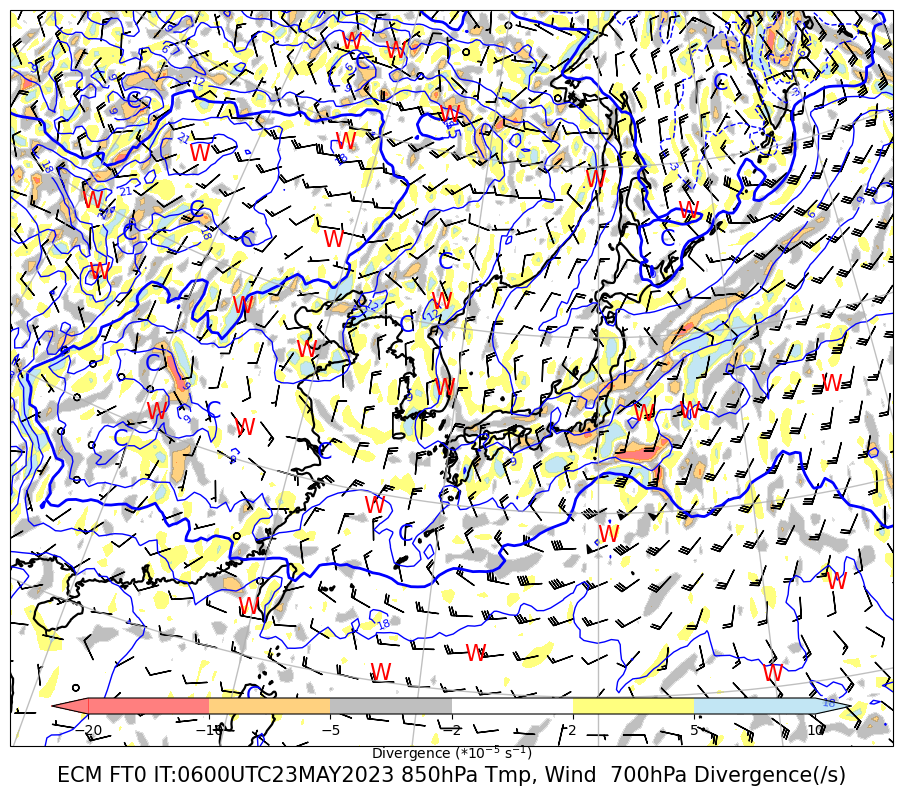

In [17]:
## 図法指定                                                                             
proj = ccrs.Stereographic(central_latitude=60, central_longitude=set_central_longitude)
latlon_proj = ccrs.PlateCarree()
## 図のSIZE指定inch                                                                        
fig = plt.figure(figsize=(10,8))
## 余白設定                                                                                
plt.subplots_adjust(left=0, right=1, bottom=0.06, top=0.98)                  
## 作図                                                                                    
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent(i_area, latlon_proj)
#
# contourf の bug回避
#  bugの症状: 配列の値のばらつきが大きいと、表示異常となる
#  対処: 配列の値が、指定したレベル値内に全ておさまるように、描画に影響しない範囲で絶対値の大きな値のみ書き換える。
div_ary = np.array(dsp['div'].values) * 1e5
(lenx,leny) = div_ary.shape
max_level = max(levels_div_hat)
min_level = min(levels_div_hat)
for x in range(lenx):
    for y in range(leny):
        v = div_ary[x][y]
        if v > max_level:
            div_ary[x][y] = max_level
        elif v < min_level:
            div_ary[x][y] = min_level
#
## 収束・発散
# 塗りつぶし
cn_div_hatch = ax.contourf(dsp['lon'], dsp['lat'], div_ary,
                            levels_div_hat, colors=levels_div_hat_color, extend='both',
                            alpha=0.5, transform=latlon_proj)
ax_reld = fig.add_axes([0.1, 0.1, 0.8, 0.02])
cb = plt.colorbar(cn_div_hatch, orientation='horizontal',
                  shrink=0.74, aspect=40, pad=0.01, cax=ax_reld,
                  ticks=levels_div_hat)
cb.set_label('Divergence (*10$^{-5}$ s$^{-1}$)')
#
# 等温度線 実線
dsp['Temperature'] = (dsp['Temperature']).metpy.convert_units(units.degC)  # Kelvin => Celsius
cn_tmp0 = ax.contour(dsp['lon'], dsp['lat'],
                     dsp['Temperature'],
                     colors='blue', linewidths=1.0, levels=levels_tmp0,
                     transform=latlon_proj )
ax.clabel(cn_tmp0, levels_tmp0i, fontsize=8,
          inline=True, inline_spacing=5,
          fmt='%i', rightside_up=True, colors='blue')
#
cn_tmp1 = ax.contour(dsp['lon'], dsp['lat'],
                     dsp['Temperature'],
                     colors='blue', linewidths=2.0, levels=levels_tmp1,
                     transform=latlon_proj )
ax.clabel(cn_tmp1, levels_tmp1, fontsize=12,
          inline=True, inline_spacing=5,
          fmt='%i', rightside_up=True, colors='blue')
#
## 海岸線
ax.coastlines(resolution='50m', linewidth=1.6) # 海岸線の解像度を上げる
if (flag_border):
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.5)
    ax.add_feature(country_borders, edgecolor='black', linewidth=0.5)
#
# グリッド線を引く                                                               
xticks=np.arange(0,360.1,dlon)
yticks=np.arange(-90,90.1,dlat)
gl = ax.gridlines(crs=ccrs.PlateCarree()
         , draw_labels=False
         , linewidth=1, alpha=0.8)
gl.xlocator = mticker.FixedLocator(xticks)
gl.ylocator = mticker.FixedLocator(yticks)
#
# 気温 W
maxid = detect_peaks(dsp['Temperature'].values, filter_size=10, dist_cut=8.0)
for i in range(len(maxid[0])):                                                      
  wlon = dsp['lon'][maxid[1][i]]
  wlat = dsp['lat'][maxid[0][i]]
  # 図の範囲内に座標があるか確認                                                        
  fig_z, _, _ = transform_lonlat_to_figure((wlon,wlat),ax,proj)
  if ( fig_z[0] > 0.05 and fig_z[0] < 0.95  and fig_z[1] > 0.05 and fig_z[1] < 0.95):
    ax.text(wlon, wlat, 'W', size=16, color="red", transform=latlon_proj)
#
# 気温 C
minid = detect_peaks(dsp['Temperature'].values, filter_size=10, dist_cut=8.0,flag=1)
for i in range(len(minid[0])):
  wlon = dsp['lon'][minid[1][i]]
  wlat = dsp['lat'][minid[0][i]]
  # 図の範囲内に座標があるか確認                                                        
  fig_z, _, _ = transform_lonlat_to_figure((wlon,wlat),ax,proj)
  if ( fig_z[0] > 0.05 and fig_z[0] < 0.95  and fig_z[1] > 0.05 and fig_z[1] < 0.95):
    ax.text(wlon, wlat, 'C', size=16, color="blue", transform=latlon_proj)
#
## 風                                                           
wind_slice = (slice(None, None, 5), slice(None, None, 5))
ax.barbs(dsp['lon'][wind_slice[0]], dsp['lat'][wind_slice[1]],    
         dsp['u_wind'].values[wind_slice] * 1.944,
         dsp['v_wind'].values[wind_slice] * 1.944,
         length=5.5,
         pivot='middle', color='black', transform=latlon_proj)
#
## 図の説明
fig.text(0.5,0.01,"ECM FT{0:d} IT:".format(i_ft)+dt_str+
         " {0}hPa Tmp, Wind  {1}hPa Divergence(/s)".format(tagHp,tagHpDiv) ,
         ha='center',va='bottom', size=15)
#
# ファイル出力
output_fig_nm="ecm_{0}UTC_FT{1:03d}_fax78{2}.png".format(dt_str2,i_ft,str_area)
plt.savefig(output_fig_nm)
print("output:{}".format(output_fig_nm))
#
## 表示
plt.show()